# LSTM Model: Training on 2004-2018 and Predicting 2019 vs 5-Year Average

In [1820]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader

## Get File path and load the csv data

In [1821]:
from util.data_path import cassava_price_avg as data_file

In [1822]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

In [1823]:
# Check the available date range in the dataset
min_year = long.index.year.min()
max_year = long.index.year.max()
print(f"Available date range: {min_year} to {max_year}")

Available date range: 2004 to 2024


## Set the training dataset and the predicted data

In [1824]:
gregorian_2004 = 2004  # Year 2004
gregorian_2018 = 2018  # Year 2018
gregorian_2019 = 2019  # Year 2019
gregorian_2024 = 2024  # Year 2024

# Training data from 2004-2018
train = long[(long.index.year >= gregorian_2004) & (long.index.year <= gregorian_2018)][
    "price"
].to_frame()
# Data to compare with (2019-2024)
future_years = long[
    (long.index.year >= gregorian_2019) & (long.index.year <= gregorian_2024)
]["price"].to_frame()
# First year for prediction (2019)
first_year_future = long[long.index.year == gregorian_2019]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

# LSTM Model for 1-Year Prediction and Comparison with 5-Year Average

In this notebook, we:
1. Train the LSTM model on data from 2004-2018
2. Predict prices for 2019 (1-year prediction)
3. Compare the predicted values with:
   - Actual 2019 prices
   - Average of 5-year prices (2019-2024)

## Create a sequence dataset class for LSTM prediction

In [1825]:
from util.lstm_cust_class import SeqDataset
from util.lstm_cust_class import LSTMRegressor

SEQ_LEN = 12
PRED_LEN = 12  # Predict 1 year (12 months)

In [1826]:
ds = SeqDataset(series, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

## Training the LSTM model

In [1827]:
model = LSTMRegressor()
crit = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    for seq, targ in loader:
        opt.zero_grad()
        pred = model(seq)
        loss = crit(pred.squeeze(), targ[:, 0])
        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch:>3}/{EPOCHS}  loss={loss.item():.5f}")

epoch  50/300  loss=0.00597
epoch 100/300  loss=0.00275
epoch 100/300  loss=0.00275
epoch 150/300  loss=0.00161
epoch 150/300  loss=0.00161
epoch 200/300  loss=0.00143
epoch 200/300  loss=0.00143
epoch 250/300  loss=0.00149
epoch 250/300  loss=0.00149
epoch 300/300  loss=0.00111
epoch 300/300  loss=0.00111


## Predict the data for the next year

In [1828]:
model.eval()
with torch.no_grad():
    window = torch.from_numpy(series[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1)
    preds = []
    for _ in range(PRED_LEN):
        nxt = model(window)
        preds.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.unsqueeze(0)], dim=1)

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

gregorian_year = 2019  # Predicting for 2019 (first year after training)
forecast = pd.Series(
    preds,
    index=pd.date_range(f"{gregorian_year}-01-01", periods=12, freq="MS"),
    name="forecast_price",
)

print("--- Forecast for 2019 ---")
print(forecast.round(2))

--- Forecast for 2019 ---
2019-01-01    2.56
2019-02-01    2.64
2019-03-01    2.67
2019-04-01    2.63
2019-05-01    2.59
2019-06-01    2.52
2019-07-01    2.49
2019-08-01    2.48
2019-09-01    2.48
2019-10-01    2.47
2019-11-01    2.46
2019-12-01    2.46
Freq: MS, Name: forecast_price, dtype: float64


In [1829]:
# Compare with the first year (2019)
cmp_first_year = pd.concat(
    [first_year_future["price"].rename("actual"), forecast], axis=1
)
print("\n--- Actual vs Forecast (2019) ---")
print(cmp_first_year.round(2))

# Calculate the average of 2019-2024 data
future_years_avg = future_years.groupby(future_years.index.month).mean().reset_index()
future_years_avg.columns = ["month", "avg_2019_2024"]
future_years_avg["month_name"] = future_years_avg["month"].apply(
    lambda x: pd.to_datetime(f"2019-{x}-01").strftime("%b")
)
future_years_avg = future_years_avg.set_index("month")

# Create a DataFrame to compare forecast with the average
forecast_monthly = pd.DataFrame(
    {"month": forecast.index.month, "forecast": forecast.values}
)
forecast_monthly = forecast_monthly.set_index("month")

# Join with the multi-year average
cmp_avg = forecast_monthly.join(future_years_avg[["avg_2019_2024"]])
cmp_avg["month_name"] = cmp_avg.index.map(
    lambda x: pd.to_datetime(f"2019-{x}-01").strftime("%b")
)

print("\n--- Forecast vs 5-Year Average (2019-2024) ---")
print(cmp_avg[["month_name", "forecast", "avg_2019_2024"]].round(2))


--- Actual vs Forecast (2019) ---
            actual  forecast_price
2019-01-01    2.53            2.56
2019-02-01    2.42            2.64
2019-03-01    2.40            2.67
2019-04-01    2.39            2.63
2019-05-01    2.29            2.59
2019-06-01    2.20            2.52
2019-07-01    2.20            2.49
2019-08-01    2.20            2.48
2019-09-01    2.20            2.48
2019-10-01    2.24            2.47
2019-11-01    2.29            2.46
2019-12-01    2.26            2.46

--- Forecast vs 5-Year Average (2019-2024) ---
      month_name  forecast  avg_2019_2024
month                                    
1            Jan      2.56           2.70
2            Feb      2.64           2.72
3            Mar      2.67           2.75
4            Apr      2.63           2.77
5            May      2.59           2.78
6            Jun      2.52           2.72
7            Jul      2.49           2.70
8            Aug      2.48           2.70
9            Sep      2.48           2.72


## Save the Forecasted Price LSTM Model

In [1830]:
import os
from datetime import datetime
from pathlib import Path

forecast_dir = Path("forecast_price")
forecast_dir = forecast_dir / "(5)-LSTM"
forecast_dir.mkdir(exist_ok=True, parents=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{data_file.parent.name}_forecast.txt"
filepath = forecast_dir / filename

# Save forecast data to text file
with open(filepath, "w") as f:
    f.write(
        f"LSTM Forecast Results for {data_file.parent.name.capitalize()} Prices (2019) {timestamp}\n"
    )
    f.write("=" * 60 + "\n\n")

    f.write("Model Configuration:\n")
    f.write("-" * 20 + "\n")
    f.write("Training Period: 2004-2018\n")
    f.write("Prediction Period: 2019\n")
    f.write("Comparison Period: 2019-2024 (5-Year Average)\n\n")

    f.write("2019 Forecast Data:\n")
    f.write("-" * 20 + "\n")
    for date, price in forecast.items():
        f.write(f"{date.strftime('%Y-%m-%d')}: {price:.2f}\n")

    f.write("\nComparison with 2019 Actual:\n")
    f.write("-" * 20 + "\n")
    f.write(f"{'Month':<10} {'Forecast':<10} {'Actual':<10} {'Error':<10}\n")
    for date, row in cmp_first_year.iterrows():
        month = date.strftime("%b")
        error = row["actual"] - row["forecast_price"]
        f.write(
            f"{month:<10} {row['forecast_price']:<10.2f} {row['actual']:<10.2f} {error:<10.2f}\n"
        )

    f.write("\nComparison with 5-Year Average (2019-2024):\n")
    f.write("-" * 20 + "\n")
    f.write(f"{'Month':<10} {'Forecast':<10} {'5-Yr Avg':<10} {'Error':<10}\n")
    for idx, row in cmp_avg.iterrows():
        month = row["month_name"]
        error = row["avg_2019_2024"] - row["forecast"]
        f.write(
            f"{month:<10} {row['forecast']:<10.2f} {row['avg_2019_2024']:<10.2f} {error:<10.2f}\n"
        )

    # Calculate basic metrics directly here
    mae_direct = mean_absolute_error(
        cmp_first_year["actual"], cmp_first_year["forecast_price"]
    )
    mape_direct = (
        abs(cmp_first_year["actual"] - cmp_first_year["forecast_price"])
        / cmp_first_year["actual"]
        * 100
    ).mean()
    accuracy_direct = 100 - (mae_direct / cmp_first_year["actual"].mean() * 100)

    mae_avg_direct = mean_absolute_error(cmp_avg["avg_2019_2024"], cmp_avg["forecast"])
    mape_avg_direct = (
        abs(cmp_avg["avg_2019_2024"] - cmp_avg["forecast"])
        / cmp_avg["avg_2019_2024"]
        * 100
    ).mean()
    accuracy_avg_direct = 100 - (mae_avg_direct / cmp_avg["avg_2019_2024"].mean() * 100)

    f.write("\nOverall Statistics (2019):\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Absolute Error: {mae_direct:.4f}\n")
    f.write(f"Mean Absolute Percentage Error: {mape_direct:.4f}%\n")
    f.write(f"Model Accuracy: {accuracy_direct:.2f}%\n")

    f.write("\nOverall Statistics (5-Year Average):\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Absolute Error: {mae_avg_direct:.4f}\n")
    f.write(f"Mean Absolute Percentage Error: {mape_avg_direct:.4f}%\n")
    f.write(f"Model Accuracy: {accuracy_avg_direct:.2f}%\n")

print(f"Forecast prices saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Forecast prices saved to: forecast_price\(5)-LSTM\cassava_forecast.txt
File size: 2130 bytes


## Compare The Error of a predicted data in a table format

In [1831]:
# Calculate error metrics for the first year (2019)
error_first_year = cmp_first_year["actual"] - cmp_first_year["forecast_price"]
abs_error_first_year = abs(error_first_year)
# Calculate absolute percentage error
abs_pct_error_first_year = abs_error_first_year / cmp_first_year["actual"] * 100
mae_first_year = mean_absolute_error(
    cmp_first_year["actual"], cmp_first_year["forecast_price"]
)
mape_first_year = abs_pct_error_first_year.mean()  # Mean Absolute Percentage Error

print("\n--- Monthly Errors (2019) ---")
error_df_first_year = pd.DataFrame(
    {
        "actual": cmp_first_year["actual"],
        "forecast": cmp_first_year["forecast_price"],
        "error": error_first_year,
        "abs_error": abs_error_first_year,
        "abs_pct_error": abs_pct_error_first_year,  # Add percentage error to the dataframe
    }
)
print(error_df_first_year.round(4))
print(f"\n2019 Mean Absolute Error: {mae_first_year:.6f}")
print(f"2019 Mean Absolute Percentage Error: {mape_first_year:.4f}%")
print(
    f"2019 LSTM Accuracy = {100 - (mae_first_year / cmp_first_year['actual'].mean() * 100):.2f}%"
)

# Calculate error metrics for the 5-year average comparison
error_avg = cmp_avg["avg_2019_2024"] - cmp_avg["forecast"]
abs_error_avg = abs(error_avg)
# Calculate absolute percentage error
abs_pct_error_avg = abs_error_avg / cmp_avg["avg_2019_2024"] * 100
mae_avg = mean_absolute_error(cmp_avg["avg_2019_2024"], cmp_avg["forecast"])
mape_avg = abs_pct_error_avg.mean()  # Mean Absolute Percentage Error

print("\n--- Monthly Errors (vs 5-Year Average 2019-2024) ---")
error_df_avg = pd.DataFrame(
    {
        "month": cmp_avg["month_name"],
        "avg_actual": cmp_avg["avg_2019_2024"],
        "forecast": cmp_avg["forecast"],
        "error": error_avg,
        "abs_error": abs_error_avg,
        "abs_pct_error": abs_pct_error_avg,
    }
)
print(error_df_avg.round(4))
print(f"\n5-Year Average Mean Absolute Error: {mae_avg:.6f}")
print(f"5-Year Average Mean Absolute Percentage Error: {mape_avg:.4f}%")
print(
    f"5-Year Average LSTM Accuracy = {100 - (mae_avg / cmp_avg['avg_2019_2024'].mean() * 100):.2f}%"
)


--- Monthly Errors (2019) ---
            actual  forecast   error  abs_error  abs_pct_error
2019-01-01    2.53    2.5632 -0.0332     0.0332         1.3127
2019-02-01    2.42    2.6359 -0.2159     0.2159         8.9195
2019-03-01    2.40    2.6701 -0.2701     0.2701        11.2530
2019-04-01    2.39    2.6341 -0.2441     0.2441        10.2122
2019-05-01    2.29    2.5922 -0.3022     0.3022        13.1951
2019-06-01    2.20    2.5162 -0.3162     0.3162        14.3708
2019-07-01    2.20    2.4934 -0.2934     0.2934        13.3372
2019-08-01    2.20    2.4791 -0.2791     0.2791        12.6851
2019-09-01    2.20    2.4825 -0.2825     0.2825        12.8426
2019-10-01    2.24    2.4729 -0.2329     0.2329        10.3992
2019-11-01    2.29    2.4643 -0.1743     0.1743         7.6094
2019-12-01    2.26    2.4572 -0.1972     0.1972         8.7238

2019 Mean Absolute Error: 0.236743
2019 Mean Absolute Percentage Error: 10.4051%
2019 LSTM Accuracy = 89.71%

--- Monthly Errors (vs 5-Year Average 2

## Plot The predicted data compare to an actual data

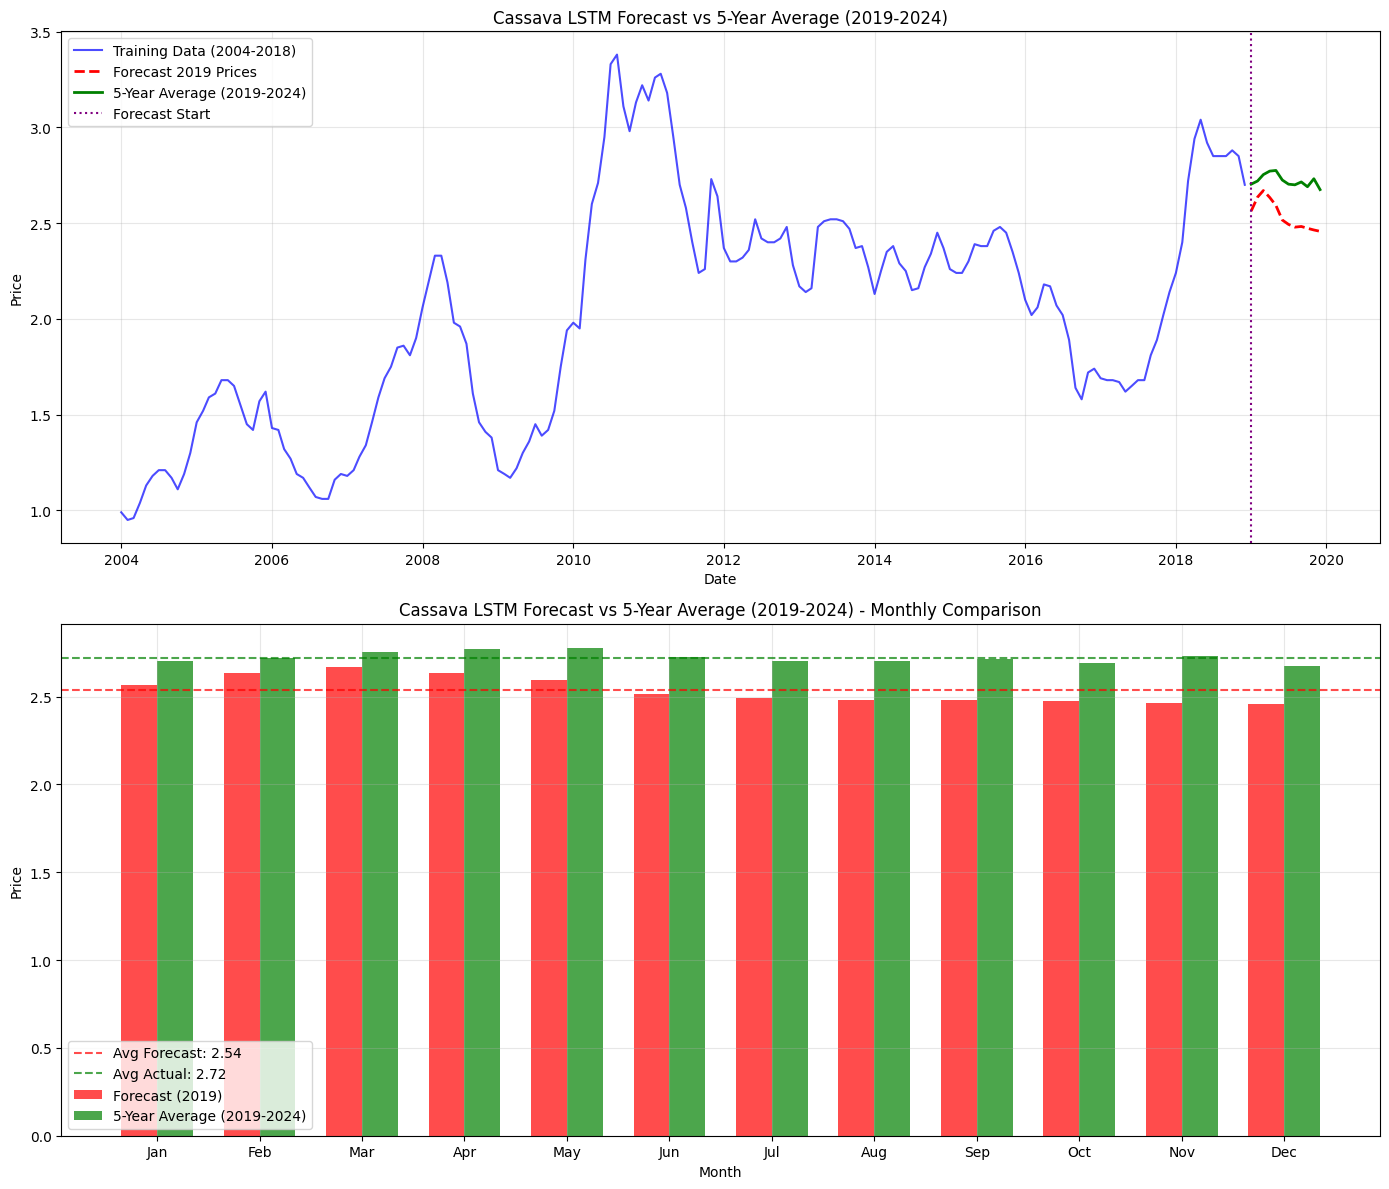

In [1832]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Comparison with training data, forecast, and 5-year average
# Get the training data for visualization
train_data = long[
    (long.index.year >= gregorian_2004) & (long.index.year <= gregorian_2018)
]

# Get the 5-year data (2019-2024)
five_year_data = long[
    (long.index.year >= gregorian_2019) & (long.index.year <= gregorian_2024)
]

# Calculate the 5-year average for each month
five_year_monthly_avg = {}
for month in range(1, 13):
    month_data = five_year_data[five_year_data.index.month == month]["price"]
    five_year_monthly_avg[month] = month_data.mean()

# Create a DataFrame with 5-year average prices
avg_dates = pd.date_range(f"{gregorian_2019}-01-01", periods=12, freq="MS")
avg_prices = [five_year_monthly_avg[date.month] for date in avg_dates]
five_year_avg_series = pd.Series(avg_prices, index=avg_dates, name="avg_2019_2024")

# Plot the data
ax1.plot(
    train_data.index,
    train_data["price"],
    label="Training Data (2004-2018)",
    color="blue",
    alpha=0.7,
)
ax1.plot(
    forecast.index,
    forecast,
    label="Forecast 2019 Prices",
    color="red",
    linewidth=2,
    linestyle="--",
)
ax1.plot(
    five_year_avg_series.index,
    five_year_avg_series.values,
    label="5-Year Average (2019-2024)",
    color="green",
    linewidth=2,
)
ax1.axvline(
    x=pd.Timestamp(f"{gregorian_year}-01-01"),
    color="purple",
    linestyle=":",
    label="Forecast Start",
)
ax1.set_title(
    f"{data_file.parent.name.capitalize()} LSTM Forecast vs 5-Year Average (2019-2024)"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Price")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Comparison with 5-year average (2019-2024) - Bar chart
# Prepare monthly data for bar chart
months = range(1, 13)
month_names = [pd.to_datetime(f"2019-{i}-01").strftime("%b") for i in months]

# Create a bar chart for comparison
width = 0.35
x = np.arange(len(month_names))

ax2.bar(
    x - width / 2,
    cmp_avg["forecast"].values,
    width,
    label="Forecast (2019)",
    color="red",
    alpha=0.7,
)
ax2.bar(
    x + width / 2,
    cmp_avg["avg_2019_2024"].values,
    width,
    label="5-Year Average (2019-2024)",
    color="green",
    alpha=0.7,
)

# Add a line showing the overall average
avg_forecast = cmp_avg["forecast"].mean()
avg_actual = cmp_avg["avg_2019_2024"].mean()
ax2.axhline(
    y=avg_forecast,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Avg Forecast: {avg_forecast:.2f}",
)
ax2.axhline(
    y=avg_actual,
    color="green",
    linestyle="--",
    alpha=0.7,
    label=f"Avg Actual: {avg_actual:.2f}",
)

# Add labels, title and legend
ax2.set_title(
    f"{data_file.parent.name.capitalize()} LSTM Forecast vs 5-Year Average (2019-2024) - Monthly Comparison"
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Price")
ax2.set_xticks(x)
ax2.set_xticklabels(month_names)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Transformer Model And Error Graph

## PLot the Error Analysis graph

<Figure size 1400x800 with 0 Axes>

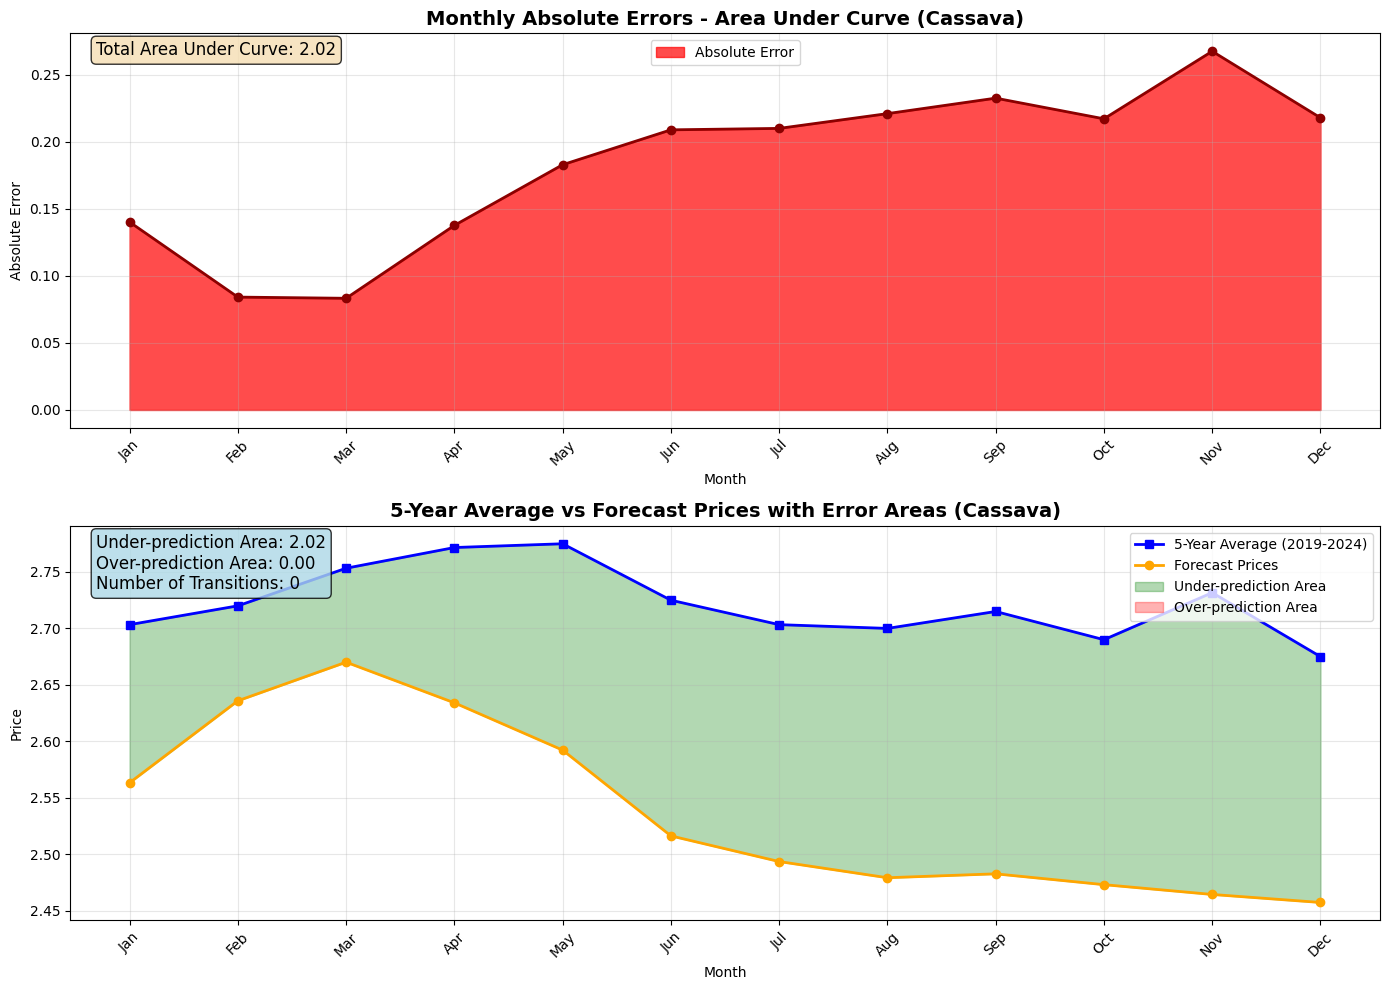

In [1833]:
# Create area plot to visualize monthly errors
plt.figure(figsize=(14, 8))

# Calculate error values (in case this cell is run before the error calculation cell)
error = cmp_avg["avg_2019_2024"] - cmp_avg["forecast"]
abs_error = abs(error)

# Add the error columns to the cmp DataFrame if they don't exist
if "error" not in cmp_avg.columns:
    cmp_avg["error"] = error
if "abs_error" not in cmp_avg.columns:
    cmp_avg["abs_error"] = abs_error

# Create month labels for better readability
month_labels = [m for m in cmp_avg["month_name"]]

# Create subplots for different error visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Area plot of absolute errors
ax1.fill_between(
    range(len(cmp_avg)),
    cmp_avg["abs_error"],
    alpha=0.7,
    color="red",
    label="Absolute Error",
)
ax1.plot(
    range(len(cmp_avg)), cmp_avg["abs_error"], color="darkred", linewidth=2, marker="o"
)
ax1.set_title(
    f"Monthly Absolute Errors - Area Under Curve ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Error")
ax1.set_xticks(range(len(cmp_avg)))
ax1.set_xticklabels(month_labels, rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add area calculation text
total_area = np.trapezoid(cmp_avg["abs_error"])
ax1.text(
    0.02,
    0.98,
    f"Total Area Under Curve: {total_area:.2f}",
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Comparison of actual vs forecast with error areas
ax2.plot(
    range(len(cmp_avg)),
    cmp_avg["avg_2019_2024"],
    label="5-Year Average (2019-2024)",
    color="blue",
    linewidth=2,
    marker="s",
)
ax2.plot(
    range(len(cmp_avg)),
    cmp_avg["forecast"],
    label="Forecast Prices",
    color="orange",
    linewidth=2,
    marker="o",
)

# Find intersection points between actual and forecast
intersect_indices = []
for i in range(1, len(cmp_avg)):
    # Check if actual and forecast cross between i-1 and i
    prev_diff = cmp_avg["avg_2019_2024"].iloc[i - 1] - cmp_avg["forecast"].iloc[i - 1]
    curr_diff = cmp_avg["avg_2019_2024"].iloc[i] - cmp_avg["forecast"].iloc[i]

    if (prev_diff * curr_diff <= 0) and (
        prev_diff != 0 or curr_diff != 0
    ):  # Sign change or one is zero
        # Linear interpolation to find exact intersection point
        if prev_diff == curr_diff:  # They're equal (both 0)
            t = 0  # At point i-1
        else:
            t = abs(prev_diff) / (abs(prev_diff) + abs(curr_diff))

        intersect_x = (i - 1) + t
        intersect_y = cmp_avg["avg_2019_2024"].iloc[i - 1] + t * (
            cmp_avg["avg_2019_2024"].iloc[i] - cmp_avg["avg_2019_2024"].iloc[i - 1]
        )

        intersect_indices.append((intersect_x, intersect_y))

# Fill areas between actual and forecast to show errors
ax2.fill_between(
    range(len(cmp_avg)),
    cmp_avg["avg_2019_2024"],
    cmp_avg["forecast"],
    where=(cmp_avg["avg_2019_2024"] >= cmp_avg["forecast"]),
    color="green",
    alpha=0.3,
    label="Under-prediction Area",
    interpolate=True,
)
ax2.fill_between(
    range(len(cmp_avg)),
    cmp_avg["avg_2019_2024"],
    cmp_avg["forecast"],
    where=(cmp_avg["avg_2019_2024"] < cmp_avg["forecast"]),
    color="red",
    alpha=0.3,
    label="Over-prediction Area",
    interpolate=True,
)

# Mark intersection points with vertical lines and markers
for idx, (x, y) in enumerate(intersect_indices):
    ax2.axvline(x, color="purple", linestyle="--", alpha=0.7, linewidth=1.5)
    ax2.plot(
        x,
        y,
        "o",
        color="purple",
        markersize=8,
        label="Intersection Point" if idx == 0 else "",
    )
    ax2.text(
        x,
        y * 1.05,
        f"Transition\n({month_labels[int(x)]})",
        ha="center",
        color="purple",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3"),
    )

ax2.set_title(
    f"5-Year Average vs Forecast Prices with Error Areas ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Price")
ax2.set_xticks(range(len(cmp_avg)))
ax2.set_xticklabels(month_labels, rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# Calculate and display area statistics
under_pred_area = np.trapezoid(
    np.maximum(cmp_avg["avg_2019_2024"] - cmp_avg["forecast"], 0)
)
over_pred_area = np.trapezoid(
    np.maximum(cmp_avg["forecast"] - cmp_avg["avg_2019_2024"], 0)
)

# Count number of transitions
num_transitions = len(intersect_indices)

# Create statistics text
stats_text = (
    f"Under-prediction Area: {under_pred_area:.2f}\n"
    f"Over-prediction Area: {over_pred_area:.2f}\n"
    f"Number of Transitions: {num_transitions}"
)

ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
)

plt.tight_layout()
plt.show()

## Analyze The Error of a predicted data

In [1834]:
# Calculate area under curve for 2019 comparison
error_first_year_series = cmp_first_year["actual"] - cmp_first_year["forecast_price"]
abs_error_first_year_series = abs(error_first_year_series)
total_area_2019 = np.trapezoid(abs_error_first_year_series)
under_pred_area_2019 = np.trapezoid(
    np.maximum(cmp_first_year["actual"] - cmp_first_year["forecast_price"], 0)
)
over_pred_area_2019 = np.trapezoid(
    np.maximum(cmp_first_year["forecast_price"] - cmp_first_year["actual"], 0)
)

# Use variables from the visualization cell for 5-year average
total_area_avg = total_area
under_pred_area_avg = under_pred_area
over_pred_area_avg = over_pred_area

print("\n--- 2019 Error Analysis ---")
print(f"Total Absolute Error Area: {total_area_2019:.4f}")
print(f"Under-prediction Area: {under_pred_area_2019:.4f}")
print(f"Over-prediction Area: {over_pred_area_2019:.4f}")
print(f"Net Error Area: {under_pred_area_2019 - over_pred_area_2019:.4f}")
print(f"Average Monthly Absolute Error: {total_area_2019 / len(cmp_first_year):.4f}")
print(
    f"Accuracy: {100 - (mae_first_year / cmp_first_year['actual'].mean() * 100):.2f}%"
)

print("\n--- 5-Year Average (2019-2024) Error Analysis ---")
print(f"Total Absolute Error Area: {total_area_avg:.4f}")
print(f"Under-prediction Area: {under_pred_area_avg:.4f}")
print(f"Over-prediction Area: {over_pred_area_avg:.4f}")
print(f"Net Error Area: {under_pred_area_avg - over_pred_area_avg:.4f}")
print(f"Average Monthly Absolute Error: {total_area_avg / len(cmp_avg):.4f}")
print(f"Accuracy: {100 - (mae_avg / cmp_avg['avg_2019_2024'].mean() * 100):.2f}%")

# Monthly breakdown for 2019
print("\n--- Monthly Error Areas (2019) ---")
for i, (date, row) in enumerate(cmp_first_year.iterrows()):
    month_label = date.strftime("%b %Y")
    error_type = (
        "Under-prediction"
        if row["actual"] > row["forecast_price"]
        else "Over-prediction"
        if row["actual"] < row["forecast_price"]
        else "Exact Match"
    )
    print(
        f"{month_label}: Abs Error = {abs_error_first_year.iloc[i]:.4f} ({error_type})"
    )

# Monthly breakdown for 5-year average
print("\n--- Monthly Error Areas (5-Year Average) ---")
for i in range(len(cmp_avg)):
    month_label = cmp_avg.iloc[i]["month_name"]
    error_type = (
        "Under-prediction"
        if cmp_avg.iloc[i]["avg_2019_2024"] > cmp_avg.iloc[i]["forecast"]
        else "Over-prediction"
        if cmp_avg.iloc[i]["avg_2019_2024"] < cmp_avg.iloc[i]["forecast"]
        else "Exact Match"
    )
    print(f"{month_label}: Abs Error = {abs_error_avg.iloc[i]:.4f} ({error_type})")

# Compare overall performance
print("\n--- Overall Comparison ---")
print(
    f"2019 Prediction Accuracy: {100 - (mae_first_year / cmp_first_year['actual'].mean() * 100):.2f}%"
)
print(
    f"5-Year Average Prediction Accuracy: {100 - (mae_avg / cmp_avg['avg_2019_2024'].mean() * 100):.2f}%"
)
print(
    f"Difference: {abs(100 - (mae_first_year / cmp_first_year['actual'].mean() * 100) - (100 - (mae_avg / cmp_avg['avg_2019_2024'].mean() * 100))):.2f}%"
)


--- 2019 Error Analysis ---
Total Absolute Error Area: 2.7257
Under-prediction Area: 0.0000
Over-prediction Area: 2.7257
Net Error Area: -2.7257
Average Monthly Absolute Error: 0.2271
Accuracy: 89.71%

--- 5-Year Average (2019-2024) Error Analysis ---
Total Absolute Error Area: 2.0234
Under-prediction Area: 2.0234
Over-prediction Area: 0.0000
Net Error Area: 2.0234
Average Monthly Absolute Error: 0.1686
Accuracy: 93.26%

--- Monthly Error Areas (2019) ---
Jan 2019: Abs Error = 0.0332 (Over-prediction)
Feb 2019: Abs Error = 0.2159 (Over-prediction)
Mar 2019: Abs Error = 0.2701 (Over-prediction)
Apr 2019: Abs Error = 0.2441 (Over-prediction)
May 2019: Abs Error = 0.3022 (Over-prediction)
Jun 2019: Abs Error = 0.3162 (Over-prediction)
Jul 2019: Abs Error = 0.2934 (Over-prediction)
Aug 2019: Abs Error = 0.2791 (Over-prediction)
Sep 2019: Abs Error = 0.2825 (Over-prediction)
Oct 2019: Abs Error = 0.2329 (Over-prediction)
Nov 2019: Abs Error = 0.1743 (Over-prediction)
Dec 2019: Abs Error = 

## Save the model Error Analysis to a file 

In [1835]:
error_record_dir = Path("error_record") / "(5)-LSTM"
error_record_dir.mkdir(exist_ok=True, parents=True)

crop_name = data_file.parent.name
filename = f"{crop_name}_error_metrics.txt"
filepath = error_record_dir / filename

In [1836]:
mae_value_2019 = mae_first_year
mape_value_2019 = mape_first_year
accuracy_2019 = 100 - (mae_first_year / cmp_first_year["actual"].mean() * 100)

mae_value_avg = mae_avg
mape_value_avg = mape_avg
accuracy_avg = 100 - (mae_avg / cmp_avg["avg_2019_2024"].mean() * 100)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save metrics to text file
with open(filepath, "w") as f:
    f.write(
        f"LSTM Model Evaluation Metrics for {crop_name.capitalize()} - {timestamp}\n"
    )
    f.write("=" * 60 + "\n\n")

    f.write("Model Configuration:\n")
    f.write("-" * 20 + "\n")
    f.write("Training Period: 2004-2018\n")
    f.write("Prediction Period: 2019\n")
    f.write("Comparison Period: 2019-2024 (5-Year Average)\n\n")

    f.write("2019 Metrics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Absolute Error (MAE): {mae_value_2019:.6f}\n")
    f.write(f"Mean Absolute Percentage Error (MAPE): {mape_value_2019:.4f}%\n")
    f.write(f"Model Accuracy: {accuracy_2019:.2f}%\n\n")

    f.write("5-Year Average (2019-2024) Metrics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Absolute Error (MAE): {mae_value_avg:.6f}\n")
    f.write(f"Mean Absolute Percentage Error (MAPE): {mape_value_avg:.4f}%\n")
    f.write(f"Model Accuracy: {accuracy_avg:.2f}%\n\n")

    f.write("Monthly Evaluation (2019):\n")
    f.write("-" * 20 + "\n")
    f.write(
        f"{'Month':<10} {'Actual':<10} {'Forecast':<10} {'Error':<10} {'Abs Error':<10} {'% Error':<10}\n"
    )

    for date, row in error_df_first_year.iterrows():
        month_label = date.strftime("%b %Y")
        f.write(
            f"{month_label:<10} {row['actual']:<10.2f} {row['forecast']:<10.2f} {row['error']:<10.4f} {row['abs_error']:<10.4f} {row['abs_pct_error']:<10.2f}%\n"
        )

    f.write("\nMonthly Evaluation (5-Year Average):\n")
    f.write("-" * 20 + "\n")
    f.write(
        f"{'Month':<10} {'5-Yr Avg':<10} {'Forecast':<10} {'Error':<10} {'Abs Error':<10} {'% Error':<10}\n"
    )

    for i, row in error_df_avg.iterrows():
        f.write(
            f"{row['month']:<10} {row['avg_actual']:<10.2f} {row['forecast']:<10.2f} {row['error']:<10.4f} {row['abs_error']:<10.4f} {row['abs_pct_error']:<10.2f}%\n"
        )

    f.write("\nArea Under Curve Analysis (2019):\n")
    f.write("-" * 20 + "\n")
    f.write(f"Total Absolute Error Area: {total_area_2019:.4f}\n")
    f.write(f"Under-prediction Area: {under_pred_area_2019:.4f}\n")
    f.write(f"Over-prediction Area: {over_pred_area_2019:.4f}\n")
    f.write(f"Net Error Area: {under_pred_area_2019 - over_pred_area_2019:.4f}\n")
    f.write(
        f"Average Monthly Absolute Error: {total_area_2019 / len(cmp_first_year):.4f}\n"
    )

    f.write("\nArea Under Curve Analysis (5-Year Average):\n")
    f.write("-" * 20 + "\n")
    f.write(f"Total Absolute Error Area: {total_area_avg:.4f}\n")
    f.write(f"Under-prediction Area: {under_pred_area_avg:.4f}\n")
    f.write(f"Over-prediction Area: {over_pred_area_avg:.4f}\n")
    f.write(f"Net Error Area: {under_pred_area_avg - over_pred_area_avg:.4f}\n")
    f.write(f"Average Monthly Absolute Error: {total_area_avg / len(cmp_avg):.4f}\n")

print(f"Evaluation metrics saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Evaluation metrics saved to: error_record\(5)-LSTM\cassava_error_metrics.txt
File size: 2917 bytes
